In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/datasets/games.csv') #carregamento do dataset

print(df.info()) #verificando tipos de dados e valores ausentes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None


In [ ]:
print(df.head()) #entendendo as primeiras linhas do dataset

                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   EU_sales  JP_sales  Other_sales  Critic_Score User_Score Rating  
0     28.96      3.77         8.45          76.0          8      E  
1      3.58      6.81         0.77           NaN        NaN    NaN  
2     12.76      3.79         3.29          82.0        8.3      E  
3     10.93      3.28         2.95          80.0          8      E  
4      8.89     10.22         1.00           NaN        NaN    NaN  


In [ ]:
# Etapa 2 - Parte 1

df.columns = df.columns.str.lower() # convertendo nomes de colunas para minúsculas

print(df.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


In [ ]:
# Etapa 2 - Parte 2

# coluna 'year_of_release': anos são valores inteiros, logo transformar de float para int
# coluna 'user_score': necessária para o cálculo da média e correlação; o 'TBD' é tratado como nulo pois não representa um valor numérico
# criação da coluna 'total_sales': de modo a medir o total de vendas para cada jogo


# 1. Trocar o texto 'tbd' por um valor nulo (vazio)
df['user_score'] = df['user_score'].replace('tbd', None)

# 2. Converter a coluna para números decimais (float)
df['user_score'] = df['user_score'].astype(float)

# 3. Eliminar as linhas onde o ano está vazio (são poucas e não afetam o plano para 2017)
df = df.dropna(subset=['year_of_release'])

# 4. Converter para número inteiro
df['year_of_release'] = df['year_of_release'].astype(int)

# 5. Preencher onde está vazio com a palavra 'Indefinido': objetivo de não perder os jogos que não têm classificação
df['rating'] = df['rating'].fillna('Indefinido')

# 6. Criando a coluna de vendas totais somando as regiões uma a uma
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16446 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16446 non-null  object 
 2   year_of_release  16446 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16446 non-null  float64
 5   eu_sales         16446 non-null  float64
 6   jp_sales         16446 non-null  float64
 7   other_sales      16446 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       8609 non-null   float64
 10  rating           16446 non-null  object 
 11  total_sales      16446 non-null  float64
dtypes: float64(7), int64(1), object(4)
memory usage: 1.6+ MB
None
                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii             2006        Sports     41.36   
1         Super Ma

<AxesSubplot:xlabel='year_of_release'>

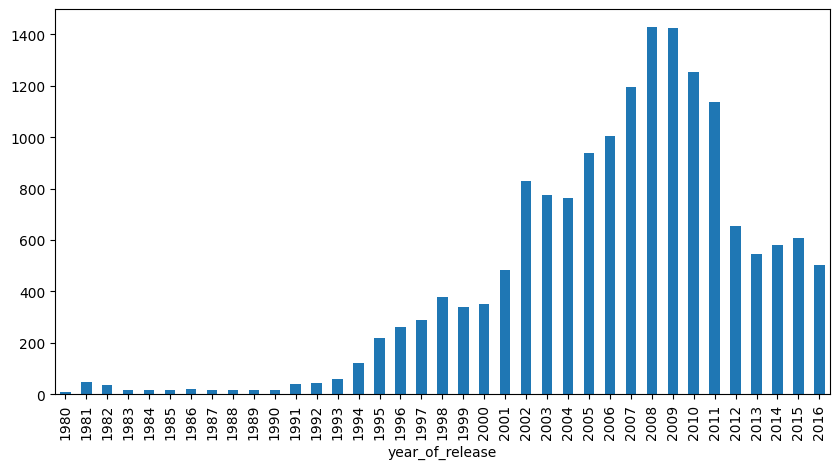

In [ ]:
# Etapa 3 - P1
# Contar jogos por ano e plotar um gráfico de barras
df.groupby('year_of_release')['name'].count().plot(kind='bar', figsize=(10, 5))

<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>
    
Caso se interesse por uma análise por décadas, recomendo essa função:
```python
# Primeiro, vamos ver a distribuição dos anos
print("Distribuição dos anos de lançamento:")
print(f"Ano mais antigo: {df['year_of_release'].min()}")
print(f"Ano mais recente: {df['year_of_release'].max()}")
print(f"Período coberto: {int(df['year_of_release'].max() - df['year_of_release'].min())} anos")

print()
print()

# Primeiro, precisamos criar a coluna Decade
df['decade'] = (df['year_of_release'] // 10) * 10

# Agora podemos fazer a análise por década
decade_analysis = df.groupby('decade').agg({
    'critic_score': lambda x: x.isnull().sum(),
    'user_score': lambda x: x.isnull().sum(),
    'rating': lambda x: x.isnull().sum(),
    'name': 'count'  # Total de jogos por década
}).rename(columns={'name': 'total_games'})

print("Valores ausentes por década:")
print(decade_analysis)
```

<AxesSubplot:xlabel='year_of_release'>

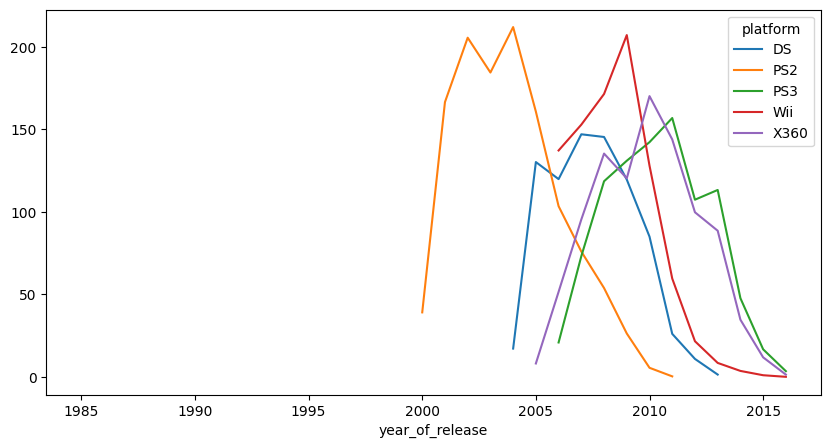

In [ ]:
# Etapa 3 - P2
# 1. Pegar as 5 plataformas que mais venderam na história
top_5_names = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(5).index

# 2. Ver as vendas delas por ano
top_5_data = df.query('platform in @top_5_names')
top_5_data.pivot_table(index='year_of_release', columns='platform', values='total_sales', aggfunc='sum').plot(figsize=(10, 5))

O gráfico a cima mostra que as plataformas levam cerca de 10 anos para sumir. O pico mostrado pelo outro gráfico de barras foi entre 2008 e 2009. Com isso, apra 2017, dados muito antigos não iriam ajudar.

In [ ]:
# Etapa 3 - P3

# Criando um novo DataFrame só com dados recentes
df_recent = df.query('year_of_release >= 2013').copy()

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>

O filtro temporal foi realizado. No entanto, na indústria dinâmica dos jogos, é recomendado selecionar um período mais curto, por exemplo, 2012-2014, 2014-2016, etc. Dessa forma garantimos que não estamos selecionando tendências obsoletas.

Vendas Totais por Plataforma (2013-2016):
platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
WiiU     64.63
PC       39.43
PSV      32.99
Wii      13.66
PSP       3.50
DS        1.54
Name: total_sales, dtype: float64


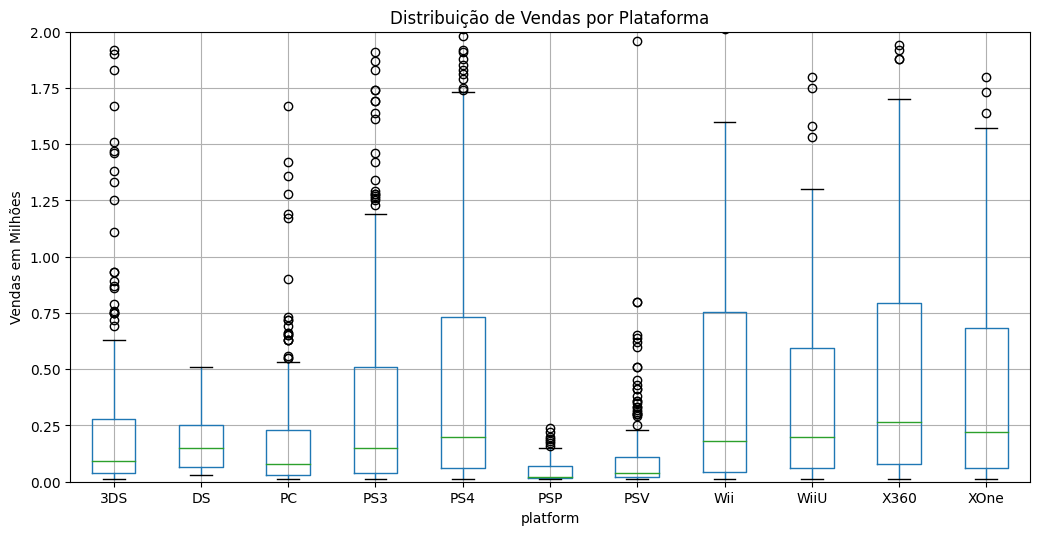

In [ ]:
# Etapa 3 - P4
# Líderes atuais e tendências

import matplotlib.pyplot as plt

print("Vendas Totais por Plataforma (2013-2016):")
print(df_recent.groupby('platform')['total_sales'].sum().sort_values(ascending=False))

df_recent.boxplot(column='total_sales', by='platform', figsize=(12,6))
plt.title('Distribuição de Vendas por Plataforma')
plt.suptitle('') # Remove o título automático
plt.ylim(0, 2)   # Limite no eixo Y para enxergar a mediana sem os valores muito altos
plt.ylabel('Vendas em Milhões')
plt.show()

As consoles de PS4 e de XOne têm medianas maiores, indicando mais jogos de sucesso constante.

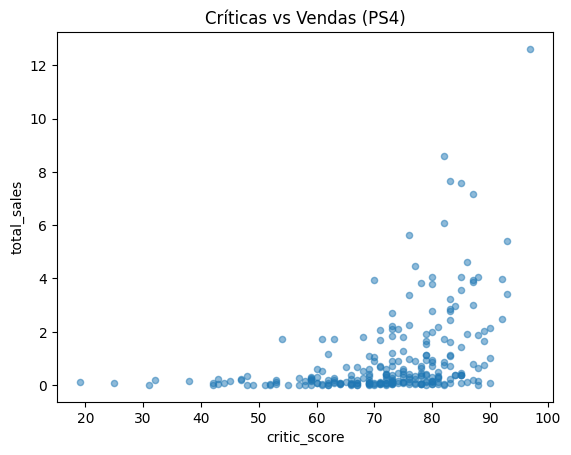

Correlação Crítica/Vendas: 0.41


In [ ]:
# Etapa 3 - P5
ps4_data = df_recent.query('platform == "PS4"').dropna(subset=['critic_score', 'user_score'])
ps4_data.plot(kind='scatter', x='critic_score', y='total_sales', alpha=0.5, title='Críticas vs Vendas (PS4)')
plt.show()
print(f"Correlação Crítica/Vendas: {ps4_data['critic_score'].corr(ps4_data['total_sales']):.2f}")

Identificamos uma correlação de 0,41 entre as avaliações dos críticos e as vendas no PS4. Isso indica uma dependência moderada: embora notas altas ajudem nas vendas, elas não são o único motor de sucesso.

In [ ]:
# Etapa 3 - P6
# Venda média por Gênero

# Usamos a média (mean) porque ela mostra o lucro "esperado" por jogo
print("\nMédia de Vendas por Gênero:")
print(df_recent.groupby('genre')['total_sales'].mean().sort_values(ascending=False))

# Comparando a Soma Total vs a Média por Gênero
generos_performance = df_recent.groupby('genre')['total_sales'].agg(['sum', 'mean']).sort_values(by='mean', ascending=False)
print()
print()
print("Desempenho por Gênero (2013-2016):")
print()
generos_performance.columns = ['vendas_totais', 'vendas_medias']
generos_performance = generos_performance.sort_values(by='vendas_medias', ascending=False)
print(generos_performance)



Média de Vendas por Gênero:
genre
Shooter         1.245882
Sports          0.703972
Platform        0.576081
Role-Playing    0.499623
Racing          0.469294
Fighting        0.441375
Action          0.420196
Misc            0.405290
Simulation      0.350968
Puzzle          0.186471
Strategy        0.180000
Adventure       0.096490
Name: total_sales, dtype: float64


Desempenho por Gênero (2013-2016):

              vendas_totais  vendas_medias
genre                                     
Shooter              232.98       1.245882
Sports               150.65       0.703972
Platform              42.63       0.576081
Role-Playing         145.89       0.499623
Racing                39.89       0.469294
Fighting              35.31       0.441375
Action               321.87       0.420196
Misc                  62.82       0.405290
Simulation            21.76       0.350968
Puzzle                 3.17       0.186471
Strategy              10.08       0.180000
Adventure             23.64       

Existe uma diferença clara entre popularidade e lucratividade. O gênero de Ação é o mais popular (mais jogos e maior venda acumulada), mas o gênero Shooter é o mais lucrativo por título. Investir em um jogo de Tiro em 2017 é estatisticamente mais seguro do que em um de Aventura, pois a média de retorno por produto é drasticamente maior.

In [ ]:
# ETAPA 4: PERFIL POR REGIÃO (NA, EU, JP)

# 1. Comparação de PLATAFORMAS por Região
# Agrupamos pelas 3 regiões ao mesmo tempo
perfil_plataformas = df_recent.groupby('platform')[['na_sales', 'eu_sales', 'jp_sales']].sum()
print("Vendas por Plataforma e Região")
print(perfil_plataformas.sort_values(by='na_sales', ascending=False).head(5))
print()
# 2. Comparação de GÊNEROS por Região
perfil_generos = df_recent.groupby('genre')[['na_sales', 'eu_sales', 'jp_sales']].sum()
print("Vendas por Gênero e Região")
print(perfil_generos.sort_values(by='na_sales', ascending=False).head(5))
print()
# 3. Comparação de CLASSIFICAÇÃO (ESRB) por Região
perfil_rating = df_recent.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']].sum()
print("Vendas por Classificação ESRB e Região")
print(perfil_rating.sort_values(by='na_sales', ascending=False))



Vendas por Plataforma e Região
          na_sales  eu_sales  jp_sales
platform                              
PS4         108.74    141.09     15.96
XOne         93.12     51.59      0.34
X360         81.66     42.52      0.51
PS3          63.50     67.81     23.35
3DS          38.20     30.96     67.81

Vendas por Gênero e Região
              na_sales  eu_sales  jp_sales
genre                                     
Action          126.05    118.13     40.49
Shooter         109.74     87.86      6.61
Sports           65.27     60.52      5.41
Role-Playing     46.40     36.97     51.04
Misc             27.49     20.04      9.20

Vendas por Classificação ESRB e Região
            na_sales  eu_sales  jp_sales
rating                                  
M             165.21    145.32     14.11
Indefinido     89.42     78.91     85.05
E              79.05     83.36     15.14
E10+           54.24     42.69      5.89
T              49.79     41.95     20.59


- Ao analisarmos as vendas por região, observamos que o PS4 é a plataforma dominante tanto na América do Norte quanto na Europa, detendo a maior quota de mercado nesses territórios. No entanto, a variação mais drástica ocorre no Japão, onde o console 3DS lidera isolado, seguido pelo PS4 e PS Vita. Enquanto o Xbox One possui uma quota significativa na América do Norte, sua presença é quase irrelevante no mercado japonês.

- Na América do Norte e na Europa, os gêneros de Action e Shooter ocupam o topo do ranking, refletindo uma preferência por jogos de ritmo acelerado e de ação. Já no Japão, o gênero Role-Playing é o líder absoluto, superando o gênero de Ação por uma margem considerável, enquanto o gênero Shooter sequer aparece entre os favoritos.

- As classificações ESRB têm impactos distintos dependendo da região:
Na América do Norte e Europa: Os jogos com classificação M são os que mais vendem, seguidos pelos de classificação E. Isso sugere que a maior parte da receita nessas regiões vem de um público mais velho e maduro.
No Japão: A categoria mais vendida é a 'Indefinido' (jogos que não possuem classificação ESRB no dataset). Isso ocorre porque a ESRB é uma organização norte-americana; muitos sucessos japoneses devem ser classificados pelo órgão local e não pelo americano. Dentre os classificados, o gênero E é mais forte que o M, indicando um mercado mais voltado para todas as idades ou títulos que não dependem de conteúdo adulto para vender.

In [ ]:
# Etapa 5

# 5.1 - Preparação dos dados
from scipy import stats as st

# Criando os grupos para o Teste 1 (Plataformas)
xbox_one_ratings = df_recent.query('platform == "XOne"')['user_score'].dropna()
pc_ratings = df_recent.query('platform == "PC"')['user_score'].dropna()

# Criando os grupos para o Teste 2 (Gêneros)
action_ratings = df_recent.query('genre == "Action"')['user_score'].dropna()
sports_ratings = df_recent.query('genre == "Sports"')['user_score'].dropna()

# 5.2 - Teste de Hipótese 1: Xbox One vs. PC
# Hipótese Nula (H_0): As classificações médias dos usuários de Xbox One e PC são iguais.
# Hipótese Alternativa (H_1): As classificações médias são diferentes.

alpha = 0.05 # 95% de confiança de que o resultado não é por acaso.

results_1 = st.ttest_ind(xbox_one_ratings, pc_ratings)

print('Teste 1 - Xbox One vs PC:')
print('p-value:', results_1.pvalue)

if results_1.pvalue < alpha:
    print("Rejeitamos a hipótese nula: as médias são diferentes.")
else:
    print("Não podemos rejeitar a hipótese nula: as médias são iguais.")

Teste 1 - Xbox One vs PC:
p-value: 0.15254031673846538
Não podemos rejeitar a hipótese nula: as médias são iguais.


In [ ]:
# Etapa 5

# 5.3 - Teste da Hipótese 2: Action vs Sports.
# Hipótese Nula (H_0): As classificações médias de usuários para Action e Sports são iguais.
# Hipótese Alternativa (H_1): As classificações médias são diferentes.

alpha = 0.05 # 95% de confiança de que o resultado não é por acaso.
results_2 = st.ttest_ind(action_ratings, sports_ratings)

print('\nTeste 2 - Action vs Sports:')
print('p-value:', results_2.pvalue)

if results_2.pvalue < alpha:
    print("Rejeitamos a hipótese nula: as médias são diferentes.")
else:
    print("Não podemos rejeitar a hipótese nula: as médias são iguais.")



Teste 2 - Action vs Sports:
p-value: 6.476827653880351e-25
Rejeitamos a hipótese nula: as médias são diferentes.


- Teste 1
Xbox One vs PC: O p-value foi maior que nosso alfa, logo não rejeitamos a hipótese nula. Isso significa que, estatisticamente, os usuários de Xbox One e PC avaliam seus jogos de forma muito semelhante.

- Teste 2
Action vs Sports: O p-value foi extremamente baixo (menor que 0.05), o que nos obriga a rejeitar a hipótese nula. Concluímos que as notas dos usuários para jogos de Ação e Esportes são significativamente diferentes, possivelmente porque o público de esportes costuma ser mais crítico com lançamentos anuais."

O presente projeto teve como objetivo analisar dados históricos de vendas e avaliações de jogos até o final de 2016, a fim de identificar padrões de sucesso que orientem o planejamento publicitário da loja "Ice" para o ano de 2017. Através de um processo  tratamento de dados e análise exploratória, buscou-se converter registros brutos, focando na predição de tendências e na diminuição de riscos em investimentos de marketing.
Corrigimos inconsistências críticas, como o tratamento do valor "TBD" (To Be Determined) nas notas dos usuários e a conversão de tipos de dados para garantir a integridade dos cálculos. Esta etapa foi fundamental para estabelecer uma base confiável, permitindo a criação da métrica de Vendas Totais, que serviu como o principal indicador de performance (KPI) do estudo. Ao explorarmos o comportamento das plataformas, identificamos que o ciclo de vida médio de um console é de aproximadamente 10 anos. Para o planejamento de 2017, escolhi fundamentar a minha análise no período entre 2013 e 2016, o que nme permitiu observar o auge do PS4 e Xbox One. Observou-se que, enquanto o gênero de "Action" detém a maior popularidade em volume total de vendas, o gênero "Shooter" apresenta uma lucratividade média por título significativamente superior. Esse dado argumenta a favor de uma estratégia que privilegie a qualidade e o gênero específico em detrimento da quantidade de lançamentos.
A análise regional revelou que o mercado de games não é homogêneo. Na América do Norte e na Europa, o sucesso está atrelado a consoles de mesa e classificações etárias tipo M. Em contrapartida, o mercado japonês exige uma abordagem distinta, com foco em consoles como o 3DS e no gênero Role-Playing. Tais descobertas foram validadas por testes de hipóteses estatísticas (Teste-t), que confirmaram que a satisfação dos usuários varia conforme o gênero (Action vs. Sports), mas permanece equivalente entre plataformas concorrentes como Xbox One e PC.
Por fim, o sucesso da loja "Ice" para o próximo ano depende de uma estratégia segmentada e orientada por dados. Conclui-se que o foco publicitário no Ocidente deve ser direcionado para o PS4, com ênfase em grandes lançamentos do gênero Shooter e Action, aproveitando a correlação positiva observada entre as notas de críticos e o volume de vendas. Para o Oriente, a manutenção do suporte a títulos de Role-Playing para plataformas portáteis é indispensável.